In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import kagglehub


data = pd.read_csv("../data/Kabeli.csv",usecols=['Date', 'Max Price', 'Min Price', 'Closing Price','Previous Closing'])
data['Date'] = pd.to_datetime(data['Date'])

start_date = '2018-01-01'
end_date = '2018-01-25'

filtered_df = data[(data['Date'] >= start_date) & (data['Date'] <= end_date)]
data=filtered_df
data.head()


,Date,Max Price,Min Price,Closing Price,Previous Closing
569,2018-01-02,342.0,336.0,342.0,336.0
570,2018-01-03,353.0,348.0,353.0,342.0
571,2018-01-04,360.0,354.0,354.0,353.0
572,2018-01-07,361.0,361.0,361.0,354.0
573,2018-01-08,355.0,355.0,355.0,361.0


Index(['Date', 'Max Price', 'Min Price', 'Closing Price', 'Previous Closing'], dtype='str')


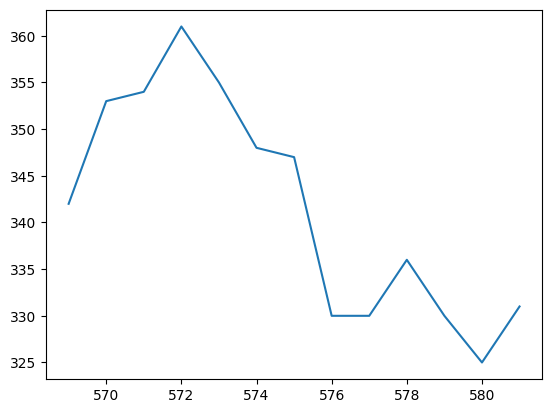

In [74]:
print(data.columns)
plt.Figure(figsize=(16,8))
plt.plot(data['Closing Price'], label='Kabeli Closing Price')

classification problem (if i should buy it or not)
and lets repesent buy with +1 and sell with -1

In [75]:
data['Open - Close'] = data['Previous Closing']- data['Closing Price']
data['High - Low'] = data['Max Price'] - data['Min Price']

data = data.dropna()



input features to predict if we should buy it or not

In [76]:
X = data[['Open - Close' , 'High - Low']]
X.head(20)

,Open - Close,High - Low
569,-6.0,6.0
570,-11.0,5.0
571,-1.0,6.0
572,-7.0,0.0
573,6.0,0.0
574,7.0,14.0
575,1.0,5.0
576,17.0,11.0
577,0.0,12.0
578,-6.0,0.0


y is a target variable for classification task

in y 
shift(-1) basically shift values by 1 and then compare > with current closing price (rommorrow > today) if its true it return 1 or else -1

In [77]:
y = np.where(data['Closing Price'].shift(-1)>data['Closing Price'],1,-1)
print(y)

[ 1  1  1 -1 -1 -1 -1 -1  1 -1 -1  1 -1]


In [78]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split( X,y,test_size=0.25,random_state=42)


KNN classifier implementaion

In [88]:
from sklearn.neighbors import KNeighborsClassifier
# from sklearn import neighbors
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# using gridsearchcv optimal value for k 
params = {'n_neighbors':[2,3,4]}
knn = KNeighborsClassifier()
model= GridSearchCV(knn,params,cv=2)

# model fit
model.fit(X_train , y_train)

#accuracy score
print("Train accuracy",accuracy_score(y_train,model.predict(X_train)))
print("Test accuracy",accuracy_score(y_test,model.predict(X_test)))


Train accuracy 0.7777777777777778
Test accuracy 0.25


In [89]:
prediction_clasification = model.predict(X_test)
actual_predicted_data = pd.DataFrame({'Actual class':y_test , 'predicted class':prediction_clasification})
actual_predicted_data.head(20)

,Actual class,predicted class
0,1,-1
1,-1,-1
2,1,-1
3,1,-1


In [95]:
y= data['Closing Price']
y

569    342.0
570    353.0
571    354.0
572    361.0
573    355.0
574    348.0
575    347.0
576    330.0
577    330.0
578    336.0
579    330.0
580    325.0
581    331.0
Name: Closing Price, dtype: float64

regression problem : KNN

In [99]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split( X,y,test_size=0.25,random_state=42)

# using gridsearchcv optimal value for k 
params = {'n_neighbors':[2,3,4,5]}
knn_reg = KNeighborsRegressor()
model_reg= GridSearchCV(knn_reg,params,cv=3)

# model fit
model_reg.fit(X_train_reg , y_train_reg)
predictions = model_reg.predict(X_test_reg)
print(predictions)

[344.         348.33333333 346.         349.66666667]


In [100]:

predictions.shape

(4,)

In [101]:
rms = np.sqrt(np.mean(np.power((np.array(y_test)-np.array(predictions)),2)))
rms

np.float64(346.5098202873268)

In [107]:
valid = pd.DataFrame({ 'Actual class':y_test_reg, 'predicted class':predictions})
valid.head(20)


,Actual class,predicted class
580,325.0,344.000000
578,336.0,348.333333
569,342.0,346.000000
577,330.0,349.666667
